In [47]:
from langgraph.graph import StateGraph, START, END
from langchain_cohere import ChatCohere
from dotenv import load_dotenv
from typing import TypedDict
from langgraph.checkpoint.memory import InMemorySaver

In [48]:
# laod env variables.
load_dotenv()

True

In [49]:
# create the LLM object. 
model = ChatCohere(
    model = 'command-a-03-2025', 
    temperature = 0.7
)

In [50]:
# create the state of the graph.
class JokeState(TypedDict): 
    topic : str 
    joke : str 
    explaination : str

In [51]:
# define the nodes of the graph. 

# define the generate_joke node. 
def generate_joke(state : JokeState):

    # extract the topic.
    topic = state['topic']

    # create the prompt.
    prompt = f'Generate the joke on the given topic - {topic}'

    # call the llm.
    response = model.invoke(prompt).content

    # update the state.
    return {
        'joke' : response
    }


# generate the generate_explaination node.
def generate_explaination(state : JokeState):

    # extract the joke from the state.
    joke = state['joke']

    # create the prompt.
    prompt = f'Generate the explaination of the given joke and the joke is - {joke}'

    # call the llm.
    response = model.invoke(prompt).content

    # update the state partially.
    return {
        'explaination' : response
    }

In [52]:
# create the checkpointer.
checkPointer = InMemorySaver()

In [53]:
# biuld the graph.
graph = StateGraph(JokeState)

# node of the graph.
graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explaination', generate_explaination)

# create the edges in the graph.
graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explaination')
graph.add_edge('generate_explaination', END)

# compile the graph.
workflow = graph.compile(checkpointer = checkPointer)

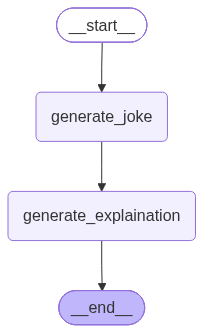

In [54]:
workflow

In [56]:
# here we define a thread to unique identify this chats using this workflow.
config1 = {
    'configurable' : {
        'thread_id' : 'user_1'
    }
}

In [57]:
# define the intial state.
intial_state = {
    'topic' : 'Pizza'
}

final_state = workflow.invoke(intial_state, config = config1)


In [58]:
final_state

{'topic': 'Pizza',
 'joke': '**Why don’t pizzas get promoted at work?**  \nBecause they’re always getting *cheesed* off and can’t *rise* to the occasion!  \n\n**What did the pizza say to the topping?**  \n"You’ve got a *slice* of my heart!"  \n\n**Why did the pizza go to therapy?**  \nIt needed help dealing with its *deep-dish* issues.  \n\n**How does a pizza greet its friends?**  \n"Hey, *dough* you want to hang out?"  \n\n**Why did the pizza break up with the garlic bread?**  \nIt said, "You’re just too *crusty* for me!"  \n\n**What’s a pizza’s favorite dance?**  \nThe *sauce-ba*!  \n\n**Why did the pizza join the gym?**  \nTo work on its *pepper-own-i*!  \n\n**What do you call a pizza that’s always on time?**  \n*Punctu-all*!  \n\n**Why did the pizza refuse to go to the party?**  \nIt didn’t want to get *topped* by the competition.  \n\n**What’s a pizza’s favorite game?**  \n*Hide and cheese*!',
 'explaination': 'These pizza jokes are a delightful blend of wordplay and puns, all cen

In [59]:
workflow.get_state(config = config1)

StateSnapshot(values={'topic': 'Pizza', 'joke': '**Why don’t pizzas get promoted at work?**  \nBecause they’re always getting *cheesed* off and can’t *rise* to the occasion!  \n\n**What did the pizza say to the topping?**  \n"You’ve got a *slice* of my heart!"  \n\n**Why did the pizza go to therapy?**  \nIt needed help dealing with its *deep-dish* issues.  \n\n**How does a pizza greet its friends?**  \n"Hey, *dough* you want to hang out?"  \n\n**Why did the pizza break up with the garlic bread?**  \nIt said, "You’re just too *crusty* for me!"  \n\n**What’s a pizza’s favorite dance?**  \nThe *sauce-ba*!  \n\n**Why did the pizza join the gym?**  \nTo work on its *pepper-own-i*!  \n\n**What do you call a pizza that’s always on time?**  \n*Punctu-all*!  \n\n**Why did the pizza refuse to go to the party?**  \nIt didn’t want to get *topped* by the competition.  \n\n**What’s a pizza’s favorite game?**  \n*Hide and cheese*!', 'explaination': 'These pizza jokes are a delightful blend of wordpla

In [60]:
complete_state_history = workflow.get_state_history(config = config1)

In [61]:
for state in complete_state_history:
    print(state)

StateSnapshot(values={'topic': 'Pizza', 'joke': '**Why don’t pizzas get promoted at work?**  \nBecause they’re always getting *cheesed* off and can’t *rise* to the occasion!  \n\n**What did the pizza say to the topping?**  \n"You’ve got a *slice* of my heart!"  \n\n**Why did the pizza go to therapy?**  \nIt needed help dealing with its *deep-dish* issues.  \n\n**How does a pizza greet its friends?**  \n"Hey, *dough* you want to hang out?"  \n\n**Why did the pizza break up with the garlic bread?**  \nIt said, "You’re just too *crusty* for me!"  \n\n**What’s a pizza’s favorite dance?**  \nThe *sauce-ba*!  \n\n**Why did the pizza join the gym?**  \nTo work on its *pepper-own-i*!  \n\n**What do you call a pizza that’s always on time?**  \n*Punctu-all*!  \n\n**Why did the pizza refuse to go to the party?**  \nIt didn’t want to get *topped* by the competition.  \n\n**What’s a pizza’s favorite game?**  \n*Hide and cheese*!', 'explaination': 'These pizza jokes are a delightful blend of wordpla

In [62]:
# here we define a thread to unique identify this chats using this workflow.
config2 = {
    'configurable' : {
        'thread_id' : 'user_2'
    }
}

In [63]:
# define the intial state.
intial_state = {
    'topic' : 'Pasta'
}

final_state = workflow.invoke(intial_state, config = config2)


In [64]:
final_state

{'topic': 'Pasta',
 'joke': 'Why did the spaghetti go to the doctor?\n\nBecause it was feeling *noodle*!',
 'explaination': 'The joke "Why did the spaghetti go to the doctor? Because it was feeling *noodle*!" plays on a pun and wordplay. Here\'s the breakdown:\n\n1. **Setup**: The question "Why did the spaghetti go to the doctor?" sets up the expectation that the spaghetti has a health issue, which is unusual since spaghetti is an inanimate object.\n\n2. **Punchline**: The punchline "Because it was feeling *noodle*!" is a play on words. The word "noodle" is a term often used to describe spaghetti or pasta, but here it’s used as a pun on the phrase "feeling lousy" or "feeling unwell." The joke humorously suggests that the spaghetti is "feeling noodle" (i.e., feeling poorly or sick), even though it’s already a noodle by nature.\n\n3. **Humor**: The humor lies in the absurdity of spaghetti, a food item, needing medical attention, combined with the clever wordplay that ties its identity (b

In [65]:
user2_history = workflow.get_state_history(config = config2)

In [66]:
for state in user2_history:
    print(state)

StateSnapshot(values={'topic': 'Pasta', 'joke': 'Why did the spaghetti go to the doctor?\n\nBecause it was feeling *noodle*!', 'explaination': 'The joke "Why did the spaghetti go to the doctor? Because it was feeling *noodle*!" plays on a pun and wordplay. Here\'s the breakdown:\n\n1. **Setup**: The question "Why did the spaghetti go to the doctor?" sets up the expectation that the spaghetti has a health issue, which is unusual since spaghetti is an inanimate object.\n\n2. **Punchline**: The punchline "Because it was feeling *noodle*!" is a play on words. The word "noodle" is a term often used to describe spaghetti or pasta, but here it’s used as a pun on the phrase "feeling lousy" or "feeling unwell." The joke humorously suggests that the spaghetti is "feeling noodle" (i.e., feeling poorly or sick), even though it’s already a noodle by nature.\n\n3. **Humor**: The humor lies in the absurdity of spaghetti, a food item, needing medical attention, combined with the clever wordplay that t

### Time Travel in Langraph.

In [67]:
workflow.get_state({
    "configurable" : {
        "thread_id" : "user_2", 
        'checkpoint_id': '1f1b8ea0-26ae-62f5-8000-bfa05aa650be'
    }
})

StateSnapshot(values={'topic': 'Pasta'}, next=('generate_joke',), config={'configurable': {'thread_id': 'user_2', 'checkpoint_id': '1f1b8ea0-26ae-62f5-8000-bfa05aa650be'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-09-25T14:04:22.761323+00:00', parent_config={'configurable': {'thread_id': 'user_2', 'checkpoint_ns': '', 'checkpoint_id': '1f1b8ea0-26ab-66a6-bfff-dab461c92664'}}, tasks=(PregelTask(id='f5a53c50-6d53-96b7-e7d7-13f0fb487352', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why did the spaghetti go to the doctor?\n\nBecause it was feeling *noodle*!'}),), interrupts=())

In [68]:
workflow.invoke(None, {'configurable': {'thread_id': 'user_2', 'checkpoint_id': '1f1b8ea0-26ae-62f5-8000-bfa05aa650be'}})

{'topic': 'Pasta',
 'joke': '**Why did the spaghetti go to the party?**\n\nBecause it heard it was going to be a *noodle* time!',
 'explaination': 'This joke plays on a pun involving the words "noodle" and "spaghetti." Here’s the breakdown:\n\n1. **Spaghetti**: A type of pasta made from long, thin strands. It’s also colloquially referred to as a "noodle."\n2. **Noodle**: Besides being a type of pasta, "noodle" can also be a slang term meaning "to think" or "to ponder." However, in this joke, it’s used in a playful, party-related context.\n3. **Noodle time**: The phrase "noodle time" sounds like "a good time" or "a fun time," but it’s a pun because it directly relates to the spaghetti (a noodle) attending the party.\n\nThe humor comes from the double meaning of "noodle" and the idea of spaghetti, personified, deciding to go to a party because it heard it would be a fun, "noodley" time. It’s a lighthearted, wordplay-based joke that relies on the listener catching the pun.'}

In [69]:
user2_history = workflow.get_state_history(config = config2)

In [70]:
for state in user2_history:
    print(state)

StateSnapshot(values={'topic': 'Pasta', 'joke': '**Why did the spaghetti go to the party?**\n\nBecause it heard it was going to be a *noodle* time!', 'explaination': 'This joke plays on a pun involving the words "noodle" and "spaghetti." Here’s the breakdown:\n\n1. **Spaghetti**: A type of pasta made from long, thin strands. It’s also colloquially referred to as a "noodle."\n2. **Noodle**: Besides being a type of pasta, "noodle" can also be a slang term meaning "to think" or "to ponder." However, in this joke, it’s used in a playful, party-related context.\n3. **Noodle time**: The phrase "noodle time" sounds like "a good time" or "a fun time," but it’s a pun because it directly relates to the spaghetti (a noodle) attending the party.\n\nThe humor comes from the double meaning of "noodle" and the idea of spaghetti, personified, deciding to go to a party because it heard it would be a fun, "noodley" time. It’s a lighthearted, wordplay-based joke that relies on the listener catching the p

### Update State.

In [72]:
workflow.update_state({"configurable": {"thread_id": "user_2", "checkpoint_id": "1f06cc6e-7232-6cb1-8000-f71609e6cec5", "checkpoint_ns": ""}}, {'topic':'samosa'})

{'configurable': {'thread_id': 'user_2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1b8eb7-3351-6a26-8000-653ec321a9f7'}}

In [73]:
list(workflow.get_state_history(config = config2))

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': 'user_2', 'checkpoint_ns': '', 'checkpoint_id': '1f1b8eb7-3351-6a26-8000-653ec321a9f7'}}, metadata={'source': 'update', 'step': 0, 'parents': {}}, created_at='2026-09-25T14:14:41.488108+00:00', parent_config={'configurable': {'thread_id': 'user_2', 'checkpoint_ns': '', 'checkpoint_id': '1f06cc6e-7232-6cb1-8000-f71609e6cec5'}}, tasks=(PregelTask(id='39cea061-4c3b-d7ee-0ad3-aed623707058', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'Pasta', 'joke': '**Why did the spaghetti go to the party?**\n\nBecause it heard it was going to be a *noodle* time!', 'explaination': 'This joke plays on a pun involving the words "noodle" and "spaghetti." Here’s the breakdown:\n\n1. **Spaghetti**: A type of pasta made from long, thin strands. It’s also colloquially referred to as a "n

In [75]:
workflow.invoke(None, {"configurable": {"thread_id": "user_2", "checkpoint_id": "1f1b8eb7-3351-6a26-8000-653ec321a9f7"}})

{'topic': 'samosa',
 'joke': '**Why did the samosa go to therapy?**\n\nBecause it was feeling *fried* inside and needed to *spice* up its life!',
 'explaination': 'This joke plays on a clever double entendre using words associated with samosas (a popular fried snack) and common emotional or psychological phrases. Here\'s the breakdown:\n\n1. **"Feeling *fried* inside"**:  \n   - Literal meaning: Samosas are fried snacks, so being "fried" is a physical characteristic.  \n   - Figurative meaning: "Fried" is often used colloquially to describe feeling mentally or emotionally exhausted, overwhelmed, or "burnt out." The samosa is humorously portrayed as experiencing emotional distress.\n\n2. **"Needed to *spice* up its life"**:  \n   - Literal meaning: Samosas are filled with spices, so "spice" is a key ingredient in their identity.  \n   - Figurative meaning: "Spice up" is an idiom meaning to make something more exciting or interesting. The samosa is seeking therapy to add excitement or ch

In [76]:
list(workflow.get_state_history(config = config2))

[StateSnapshot(values={'topic': 'samosa', 'joke': '**Why did the samosa go to therapy?**\n\nBecause it was feeling *fried* inside and needed to *spice* up its life!', 'explaination': 'This joke plays on a clever double entendre using words associated with samosas (a popular fried snack) and common emotional or psychological phrases. Here\'s the breakdown:\n\n1. **"Feeling *fried* inside"**:  \n   - Literal meaning: Samosas are fried snacks, so being "fried" is a physical characteristic.  \n   - Figurative meaning: "Fried" is often used colloquially to describe feeling mentally or emotionally exhausted, overwhelmed, or "burnt out." The samosa is humorously portrayed as experiencing emotional distress.\n\n2. **"Needed to *spice* up its life"**:  \n   - Literal meaning: Samosas are filled with spices, so "spice" is a key ingredient in their identity.  \n   - Figurative meaning: "Spice up" is an idiom meaning to make something more exciting or interesting. The samosa is seeking therapy to 